In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


### EDA

In [3]:
path = 'HAM10000_metadata.csv'

In [4]:
df = pd.read_csv(path)

In [5]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [6]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [7]:
df['age'] = df['age'].fillna(df['age'].mean())

In [8]:
df.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

In [9]:
df.shape

(10015, 7)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           10015 non-null  float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 990.6 KB


In [11]:
df.describe()

,age
count,10015.000000
mean,51.863828
std,16.920252
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
df.head(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back


In [12]:
df.tail(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization
10005,HAM_0005579,ISIC_0028393,akiec,histo,80.0,male,face
10006,HAM_0004034,ISIC_0024948,akiec,histo,55.0,female,face
10007,HAM_0001565,ISIC_0028619,akiec,histo,60.0,female,face
10008,HAM_0001576,ISIC_0033705,akiec,histo,60.0,male,face
10009,HAM_0005705,ISIC_0031430,akiec,histo,75.0,female,lower extremity
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back


In [13]:
print(df['dx'].unique())
print(df['localization'].unique())

<ArrowStringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str
<ArrowStringArray>
[          'scalp',             'ear',            'face',            'back',
           'trunk',           'chest', 'upper extremity',         'abdomen',
         'unknown', 'lower extremity',         'genital',            'neck',
            'hand',            'foot',           'acral']
Length: 15, dtype: str


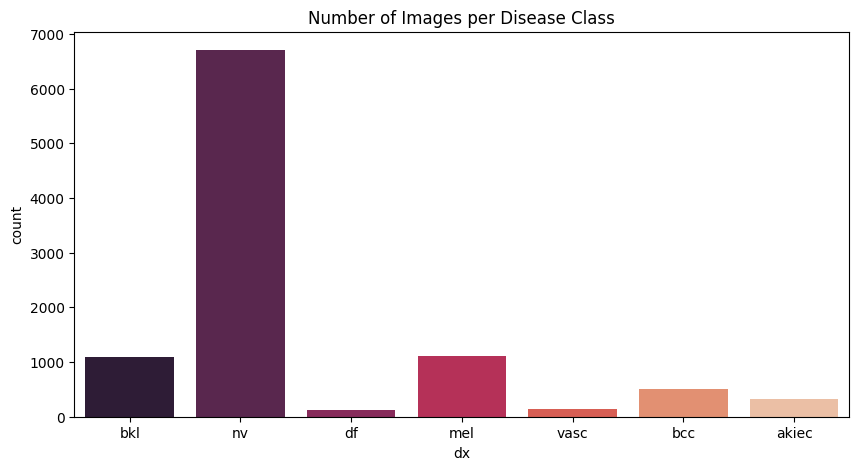

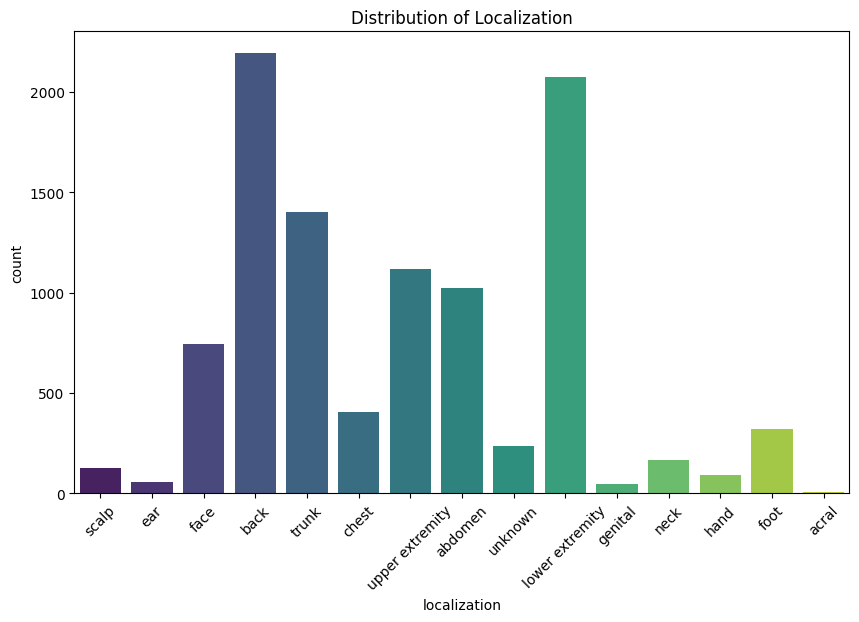

In [14]:


# (Target Distribution)
plt.figure(figsize=(10,5))
sns.countplot(x='dx', data=df, hue='dx', palette='rocket', legend=False)
plt.title('Number of Images per Disease Class')
plt.show()

# (Localization Distribution)
plt.figure(figsize=(10,6))
# 'skyblue' এর বদলে 'viridis' বা 'Set3' ব্যবহার করা হয়েছে
sns.countplot(x='localization', data=df, hue='localization', palette='viridis', legend=False)
plt.title('Distribution of Localization')
plt.xticks(rotation=45)
plt.show()

### Data Pre-processing

In [72]:
import os


# ১. যেহেতু আপনি অলরেডি ঐ ফোল্ডারেই আছেন, শুধু ফোল্ডারের নাম দিন
base_dir = 'skin_lesion_image'

# ২. সরাসরি ওই ফোল্ডারের সব .jpg ফাইল খুঁজুন
all_image_paths = glob(os.path.join(base_dir, '*.jpg'))

# অথবা যদি সাব-ফোল্ডার থাকে তবে এটি ব্যবহার করুন:
# all_image_paths = glob(os.path.join(base_dir, '**', '*.jpg'), recursive=True)

In [71]:
import os 
print(os.listdir())

['.ipynb_checkpoints', 'HAM10000_metadata.csv', 'skin_lesion_image', 'skin_lesion_severity.ipynb']


In [73]:
df['label'] = df['dx'].astype('category').cat.codes

In [74]:
from PIL import Image
import numpy as np
import os

images = []

for x in df['path']:
    try:
        if os.path.exists(x):
            img = Image.open(x).resize((100, 75))
            images.append(np.asarray(img))
        else:
            images.append(None)
    except:
        images.append(None)

df['image'] = images


### Data Preparation for Model Training

In [43]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [75]:
import numpy as np

# নিশ্চিত হোন যে df['image'] এ ডেটা আছে
if 'image' in df.columns and len(df['image']) > 0:
    X = np.asarray(df['image'].tolist())
    X = X / 255.0  # Normalization
    y = df['label']
    print("ডেটা সাকসেসফুলি লোড হয়েছে। মোট স্যাম্পল:", len(X))
else:
    print("এরর: আপনার 'image' কলামটি খালি! আগে ইমেজ লোড করার কোডটি রান করুন।")

এরর: আপনার 'image' কলামটি খালি! আগে ইমেজ লোড করার কোডটি রান করুন।


In [45]:
from sklearn.model_selection import train_test_split

# ২০% ডেটা পরীক্ষার (Testing) জন্য আলাদা রাখা হচ্ছে
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
from tensorflow.keras.utils import to_categorical

# লেবেলগুলোকে ক্যাটাগরিকাল ফরম্যাটে রূপান্তর
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100, 75, 3)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax') # ৭টি রোগের জন্য ৭টি আউটপুট নোড
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [32]:
print(len(df))
print(len(X))
print(len(y))

0
0
0
